# 축 후보 공간의 독립성 풍경 — 왜 '선택'이 필요했고, 어떻게 정당화되는가

이 노트북의 질문: **"컬럼들이 대부분 서로 독립이라면, 독립인 축 조합은 도대체 몇 개나 되는가?"**

> 4권역 Training 전체 10,240건 기준(03과 동일 데이터).

결론 미리보기: 3축 조합 3,276개 중 2,247개(69%)가 독립 기준을 통과한다. 즉 **통계만으로는 유일한 축 조합이 결정되지 않으며**, 최종 선택에는 반드시 통계 밖의 기준이 필요하다. 이 노트북은 그 선택 과정을 숨기지 않고 퍼널로 명시해, "임의로 골랐다"가 아니라 "**통계가 거를 수 있는 것은 다 거른 뒤, 남은 동률 후보를 명시적 기준으로 골랐다**"임을 보인다.

In [1]:
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..')
feat = pd.read_parquet(ROOT / 'data/processed/features_axis_candidates.parquet')
feat['visits_per_day'] = feat['n_tourism_visits'] / feat['trip_days']

# 축으로 검토했던 컬럼 + 그냥 데이터로 쓰는 컬럼(연령대·동반자수 등)까지 모두 포함
COLS = [c for c in feat.columns if c.startswith('category_share_')] + [
    'category_entropy', 'n_tourism_visits', 'visits_per_day', 'speed_z',
    'motive_purpose_ratio', 'motive_convenience_ratio', 'motive_revisit_reason_ratio',
    'revisit_ratio', 'path_length_km', 'route_inefficiency_ratio', 'mode_diversity',
    'total_spend_won', 'per_person_spend_won', 'trip_days',
    'TRAVEL_COMPANIONS_NUM', 'AGE_GRP',
]
# hotplace_ratio 제외 — 지표 정의 자체에 문제가 있어 후보 풀에서 뺀다.
#  (1) 핫플 2,374곳 중 1,192곳(50.2%)이 표본에 딱 2번 등장한 장소다. 인기가 아니라 표본 노이즈.
#  (2) 방문지명이 자유 입력이라 같은 곳이 쪼개진다 — '해운대' 포함 표기만 108개(합계 362회, 최다 표기 120회).
#      같은 장소가 여러 이름으로 갈리면 방문 횟수가 과소 집계되어 핫플 판정이 뒤집힌다.
#  (3) 핫플 목록을 같은 표본의 방문 빈도로 정의하므로, 개인의 비율이 자기 자신이 포함된 집계에 의존한다(순환).
X = feat[COLS].replace([np.inf, -np.inf], np.nan)
print(f'후보 컬럼 {len(COLS)}개, 쌍 {len(COLS)*(len(COLS)-1)//2}개')

후보 컬럼 28개, 쌍 378개


## 1. 상관의 전경 — 얼마나 독립적인가

28개 컬럼의 모든 쌍(378개)에 대해 |Spearman|을 계산한다. Spearman을 쓰는 이유: 지출액의 긴 꼬리, 비효율 ratio의 스파이크 등 비정규 분포에 강건하기 때문.

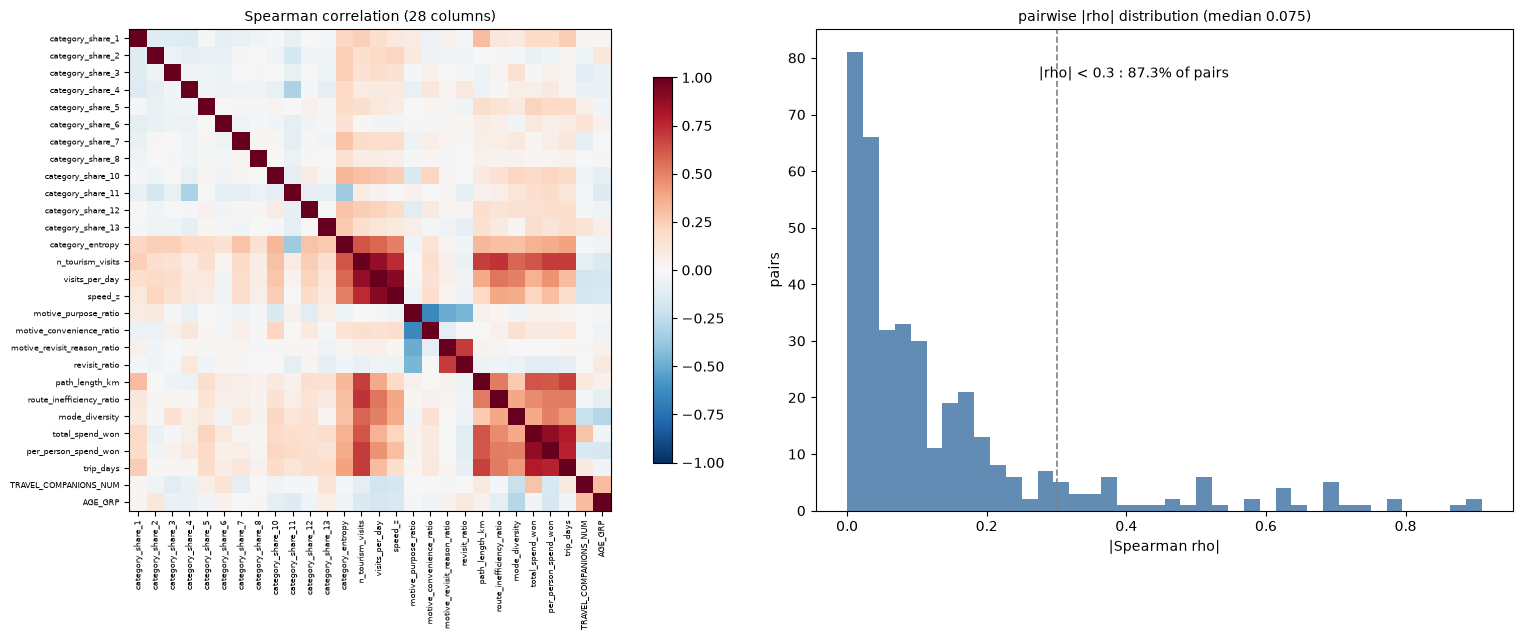

독립 쌍(|rho|<0.3): 330 / 378 (87.3%)


In [2]:
corr = X.corr(method='spearman')
acorr = corr.abs()
pair_vals = np.array([acorr.iloc[i, j] for i in range(len(COLS)) for j in range(i + 1, len(COLS))])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6.5), width_ratios=[1.2, 1])
im = ax1.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax1.set_xticks(range(len(COLS)), COLS, rotation=90, fontsize=6)
ax1.set_yticks(range(len(COLS)), COLS, fontsize=6)
ax1.set_title(f'Spearman correlation ({len(COLS)} columns)', fontsize=10)
fig.colorbar(im, ax=ax1, shrink=0.8)
ax2.hist(pair_vals, bins=40, color='#4878a8', alpha=0.85)
ax2.axvline(0.3, color='gray', ls='--', lw=1.2)
ax2.annotate(f'|rho| < 0.3 : {(pair_vals < 0.3).mean():.1%} of pairs', xy=(0.32, 0.9),
             xycoords='axes fraction', fontsize=10)
ax2.set_xlabel('|Spearman rho|'); ax2.set_ylabel('pairs')
ax2.set_title(f'pairwise |rho| distribution (median {np.median(pair_vals):.3f})', fontsize=10)
fig.tight_layout()
fig.savefig(ROOT / 'outputs/figures/independence_corr_overview.png', dpi=110)
plt.show()
print(f'독립 쌍(|rho|<0.3): {(pair_vals<0.3).sum()} / {len(pair_vals)} ({(pair_vals<0.3).mean():.1%})')

**읽는 법**: 히트맵이 거의 흰색(0 근처)이다 — 강한 상관은 파생 관계가 있는 소수 쌍(방문지 수↔하루당 방문지↔속도, 총지출↔1인지출, 여행일수↔지출)뿐이다. 쌍의 87%가 |ρ| < 0.3으로 사실상 독립이고 중앙값은 0.075다.

이것이 시사하는 바: 관광 행동은 소수의 강한 축으로 압축되는 현상이 아니라 **저차원으로 잘 눌리지 않는 다차원적 현상**이다(01 노트북의 완만한 PCA scree와 일치). 어떤 카테고리를 좋아하는지, 동선을 어떻게 짜는지, 왜 그곳을 골랐는지(목적이냐 편의냐)는 서로 거의 무관한 별개의 선택이다.

## 2. 선택 퍼널 — 통계가 거른 것과 사람이 고른 것

3축 조합 전체에서 시작해 단계별로 거른다.

1. **독립성 필터** (통계): 세 쌍 모두 |ρ| < 0.3
2. **축 자격 필터** (통계): **퍼짐 하위 30%를 제외**한다. 퍼짐 = min-max 분산
   - 퍼짐 = 1~99% 분위수로 클리핑 후 [0,1] 스케일한 분산. 단위가 다른 컬럼끼리 비교하기 위함이고, 이론상 최대 0.25(값이 양 끝에 반반 몰릴 때)다.
   - 퍼지지 않은 컬럼은 어디서 잘라도 한쪽에 몰려 축이 성립하지 않는다.
   - **왜 절대 임계값이 아니라 하위 30%인가**: 퍼짐 값은 0.0236~0.0803에 연속적으로 깔려 있어 "이 값 이상이면 축 자격"이라 할 자연 경계가 없다. 임계값을 손으로 고르면 그 숫자에 근거가 없고, 평균(0.0475)이나 중앙값(0.0453)으로 자르면 채택 축인 `category_entropy`(0.0444)가 탈락한다. 그래서 절대값 대신 **분포에서 유도하는 비율 규칙**을 쓰고, 컷 값은 코드가 계산한다.
   - 결과적으로 컷은 0.0390에 놓이는데, 이 지점이 정렬된 퍼짐 값의 **벌어진 틈**(0.0386 ~ 0.0422, 폭 0.0036) 안이다. 값이 촘촘한 곳이 아니라 틈에서 잘리므로 표본이 조금 흔들려도 통과 여부가 뒤집히지 않는다. 규칙과 자연 절단점이 같은 곳을 가리킨 셈이다.
   - 하위 50%까지 올리면 선택 조합이 탈락한다(40%까지는 생존). 30%는 그 한계에서 여유를 둔 값이다.
3. **성향·해석 필터** (기준 기반 선택): 아래 §4의 명시적 기준

축 자격(퍼짐 하위 30% 제외 → 컷 0.0390): 19/28개 통과, 9개 탈락
    0.0386  per_person_spend_won
    0.0370  category_share_13
    0.0355  category_share_6
    0.0354  path_length_km
    0.0352  TRAVEL_COMPANIONS_NUM
    0.0351  total_spend_won
    0.0337  category_share_12
    0.0268  category_share_5
    0.0236  category_share_8
  컷이 놓인 틈: 0.0386 ~ 0.0422 (폭 0.0036)


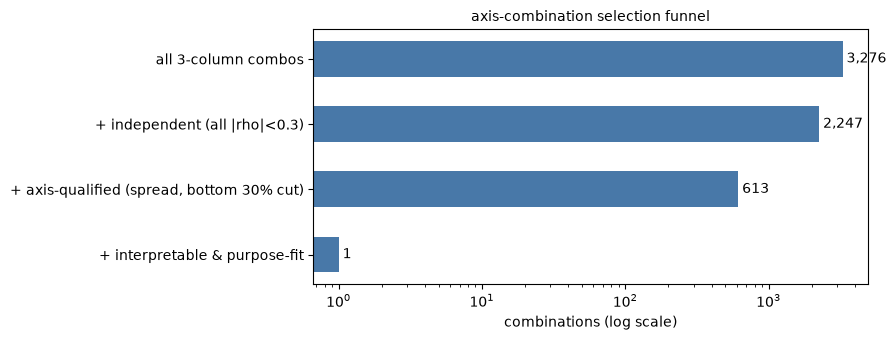

전체 3276 → 독립 2247 (69%) → 축자격 613 → 최종 1


In [3]:
acorr_np = acorr.to_numpy()
idx = {c: i for i, c in enumerate(COLS)}

# 축 자격 = 퍼짐(min-max 분산). 1~99% 클리핑 후 [0,1] 스케일한 분산이라 컬럼 간 비교가 되고,
# 이론상 최대는 0.25(값이 양 끝에 반반 몰릴 때).
def minmax_var(c):
    x = X[c].dropna().to_numpy(float)
    a, b = np.quantile(x, [0.01, 0.99])
    if b <= a: return 0.0
    y = (np.clip(x, a, b) - a) / (b - a)
    return y.var()

# 절대 임계값은 근거를 댈 수 없다(§2 설명). 하위 몇 %를 자를지만 정하고 컷 값은 데이터에서 유도한다.
SPREAD_DROP_FRAC = 0.30
mm = {c: minmax_var(c) for c in COLS}
SPREAD_MIN = float(np.quantile(list(mm.values()), SPREAD_DROP_FRAC))
qcols = [c for c in COLS if mm[c] >= SPREAD_MIN]
dropped = [c for c in COLS if mm[c] < SPREAD_MIN]
print(f'축 자격(퍼짐 하위 {SPREAD_DROP_FRAC:.0%} 제외 → 컷 {SPREAD_MIN:.4f}): '
      f'{len(qcols)}/{len(COLS)}개 통과, {len(dropped)}개 탈락')
for c in sorted(dropped, key=lambda c: -mm[c]):
    print(f'    {mm[c]:.4f}  {c}')

# 컷이 값들이 촘촘한 곳을 가르면 표본이 조금만 흔들려도 통과 여부가 뒤집힌다.
# 벌어진 틈에 떨어졌는지 확인한다.
sv = np.sort(list(mm.values()))
below, above = sv[sv < SPREAD_MIN].max(), sv[sv >= SPREAD_MIN].min()
print(f'  컷이 놓인 틈: {below:.4f} ~ {above:.4f} (폭 {above - below:.4f})')

def is_indep(t):
    return all(acorr_np[idx[a], idx[b]] < 0.3 for a, b in combinations(t, 2))

n_all = len(list(combinations(COLS, 3)))
indep_all = [t for t in combinations(COLS, 3) if is_indep(t)]
indep_qual = [t for t in combinations(qcols, 3) if is_indep(t)]
funnel = [('all 3-column combos', n_all),
          ('+ independent (all |rho|<0.3)', len(indep_all)),
          (f'+ axis-qualified (spread, bottom {SPREAD_DROP_FRAC:.0%} cut)', len(indep_qual)),
          ('+ interpretable & purpose-fit', 1)]
fig, ax = plt.subplots(figsize=(9, 3.5))
names = [f[0] for f in funnel][::-1]; vals = [f[1] for f in funnel][::-1]
ax.barh(names, vals, color='#4878a8', height=0.55)
for i, v in enumerate(vals):
    ax.text(v, i, f' {v:,}', va='center', fontsize=10)
ax.set_xscale('log'); ax.set_xlabel('combinations (log scale)')
ax.set_title('axis-combination selection funnel', fontsize=10)
fig.tight_layout()
fig.savefig(ROOT / 'outputs/figures/independence_funnel.png', dpi=110)
plt.show()
print(f'전체 {n_all} → 독립 {len(indep_all)} ({len(indep_all)/n_all:.0%}) → 축자격 {len(indep_qual)} → 최종 1')

## 3. 남은 613개는 통계적으로 동률인가 — 퍼짐 점수로 순위 확인

독립 + 축 자격을 통과한 조합들을 객관 지표 하나(세 컬럼 min-max 분산의 평균 = 퍼짐)로 점수를 매겨, 우리가 고른 조합(동선비효율 × 엔트로피 × 동기)이 어디쯤인지 확인한다.

> **읽을 때 주의**: §2의 축 자격 필터와 여기의 점수가 **같은 지표(퍼짐)** 다. 따라서 아래 히스토그램은 이미 `SPREAD_MIN` 아래가 잘려 나간 분포이고, '상위 X%'는 그 잘린 풀 안에서의 순위다. 많이 자를수록 퍼짐 낮은 조합이 먼저 사라지므로 **선택 조합의 순위는 오히려 나빠진다** — 하위 0% 제거 시 상위 14%, 10%에서 21%, 20%에서 28%, **30%에서 41%**, 40%에서 51%, 50%에서는 아예 탈락한다. 즉 이 순위는 필터를 얼마나 세게 걸었느냐의 함수일 뿐이므로, 순위를 자랑하는 지표가 아니라 **퇴화 조합이 아님을 확인하는 하한 점검**으로 읽어야 한다.

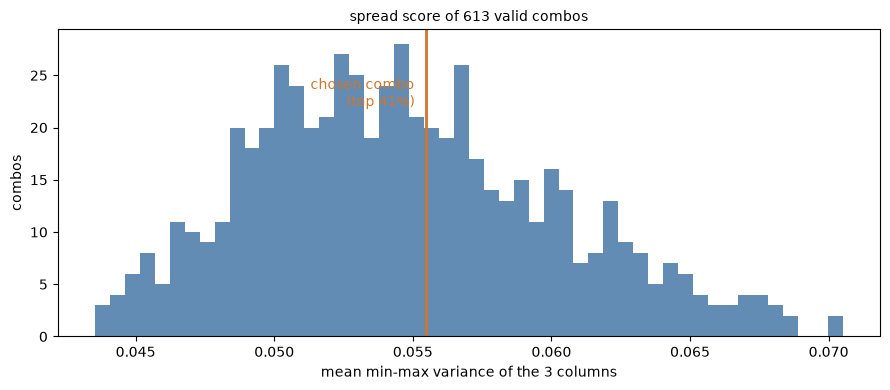

선택 조합 점수 0.0555, 상위 40.8%

퍼짐 점수 상위 5개 조합:
  ('revisit_ratio', 'mode_diversity', 'AGE_GRP') 0.0705
  ('motive_purpose_ratio', 'mode_diversity', 'AGE_GRP') 0.0703
  ('motive_convenience_ratio', 'mode_diversity', 'AGE_GRP') 0.0688
  ('revisit_ratio', 'trip_days', 'AGE_GRP') 0.0685
  ('motive_purpose_ratio', 'trip_days', 'AGE_GRP') 0.0683


In [4]:
# minmax_var, mm 은 §2에서 이미 정의됨 (축 자격 필터와 동일 지표)
scores = np.array([np.mean([mm[c] for c in t]) for t in indep_qual])
CHOSEN = tuple(sorted(('route_inefficiency_ratio', 'category_entropy', 'motive_purpose_ratio')))
ci = next(i for i, t in enumerate(indep_qual) if tuple(sorted(t)) == CHOSEN)
pct_above = (scores > scores[ci]).mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(scores, bins=50, color='#4878a8', alpha=0.85)
ax.axvline(scores[ci], color='#d1752b', lw=2)
ax.annotate(f'chosen combo\n(top {pct_above:.0%})', xy=(scores[ci], 0.75), xycoords=('data', 'axes fraction'),
            fontsize=10, color='#d1752b', ha='right', xytext=(-8, 0), textcoords='offset points')
ax.set_xlabel('mean min-max variance of the 3 columns'); ax.set_ylabel('combos')
ax.set_title(f'spread score of {len(indep_qual):,} valid combos', fontsize=10)
fig.tight_layout()
fig.savefig(ROOT / 'outputs/figures/independence_triple_scores.png', dpi=110)
plt.show()
print(f'선택 조합 점수 {scores[ci]:.4f}, 상위 {pct_above:.1%}')
print('\n퍼짐 점수 상위 5개 조합:')
for i in np.argsort(-scores)[:5]:
    print(' ', indep_qual[i], round(scores[i], 4))

## 4. 정당화 — 이것은 한계인가?

### 관찰: 객관 점수만으로 고르면 이상한 축이 뽑힌다

퍼짐 점수 1~5위 조합에는 **연령대(AGE_GRP)**, **이동수단다양성(mode_diversity)** 이 들어 있다. 연령대는 우리 데모의 **입력 변수**라 축이 되면 순환이고(연령대를 입력받아 연령대를 알려주는 꼴), 인구 속성이지 여행 **성향**도 아니다. mode_diversity는 기존 axis_scorecard에서 동점비율 31%로 이진화가 무너지는 컬럼이다. 즉 **통계 점수 1등을 기계적으로 고르는 것이야말로 잘못된 선택**이며, 통계 밖의 기준이 반드시 개입해야 한다.

### 우리가 적용한 명시적 기준

1. **성향 축일 것** — 입력·인구·상황 변수(연령대, 동반자수, 여행일수, 지출액)는 제외 (§7, axis_scorecard의 상황R² 근거)
2. **사분면 네이밍 가능** — 축의 양 끝과 조합에 사람이 읽을 수 있는 이름이 붙어야 서비스(여행 MBTI)가 성립
3. **추천으로 연결될 것** — 동선 스타일(J/P), 콘텐츠 다양성, 방문 동기(목적형/편의형)는 각각 추천 로직에 직접 매핑됨
4. **퇴화 조합이 아닐 것** — 선택 조합은 613개 중 퍼짐 상위 41%. §3의 주의대로 이 순위는 필터와 같은 지표 위에서 계산되고 필터를 세게 걸수록 나빠지므로, **하한 확인**으로만 쓰고 최대화 대상으로 삼지 않는다

> **후보 풀에서 핫플 방문 비율을 제외했다**(§1 코드 주석). 지표 정의가 표본 노이즈와 이름 표기 흔들림에 좌우되어 신뢰할 수 없기 때문이다. 핫플을 넣고 계산하면 퍼짐 점수 상위권을 핫플 낀 조합이 독식하는데, 그 상위권 자체가 위 결함 위에 서 있어 비교 기준이 되지 못한다. 같은 하위 30% 규칙에서 핫플을 넣으면 통과 컬럼 20개·조합 759개에 선택 조합은 상위 49%, 빼면 19개·613개에 **상위 41%**로 오히려 올라간다.

### 결론

이 상황은 우리 데이터의 결함이 아니라 **비지도 유형화의 표준적 상황**이다. 통계는 나쁜 축(상관 높음, 단봉 그라데이션, 상황 종속)을 **걸러줄 수는 있어도**, 동등하게 유효한 직교 표현들 사이에서 **하나를 골라줄 수는 없다**. 그 마지막 선택을 임의(arbitrary)가 아니라 **기준 기반(criterion-based)**으로 만들고 기준을 공개하는 것이 정당화의 전부이며, 이 노트북이 그 기록이다.

**발표용 문장**: "독립성과 축 자격을 모두 통과한 3축 조합이 613개나 됩니다. 통계는 여기까지만 데려다주기 때문에, 저희는 성향일 것·이름 붙을 것·추천에 쓰일 것이라는 세 기준을 세워 선택했습니다. 퍼짐 점수로는 613개 중 상위 41%인데, 이 점수는 축 자격 필터와 같은 지표라 높을수록 좋은 값이 아니라 퇴화 조합이 아님을 확인하는 용도입니다. 다른 유효한 조합이 존재한다는 것은 한계이자, 이 데이터로 만들 수 있는 여행자 유형이 그만큼 풍부하다는 뜻이기도 합니다."